In [1]:
import sys 
sys.path.append('../')
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np
import torch.nn.functional as F
from utils import injection1d, interp1d, matrl2_error, rl2_error
from model import MLP, GMGN
import scipy
import pandas as pd

Cosine - 513

In [ ]:
l = 9
n = 2**l+1
s = 2**(l-1)
x = torch.linspace(-1,1,2*n-1)

A_gt = torch.cos(torch.linspace(-1,1,2*n-1).abs())
A_tgl = np.load('../results/logarithm_513/toep_gl-relu-0/approx_kernel.npy')[0,0] * s
A_tgmg = np.load('../results/logarithm_513/toep_mg-0-0-1/approx_kernel.npy')[0,0] * s

hist_tgl = pd.read_csv('../results/logarithm_513/toep_gl-relu-0/hist.csv')
hist_tgmg = pd.read_csv('../results/logarithm_513/toep_mg-0-0-1/hist.csv')
hist_fno = pd.read_csv('../results/logarithm_513/fno-0/hist.csv')


Logarithm - 513

In [79]:
l = 9
n = 2**l+1
s = 2**(l-1)
x = torch.linspace(-1,1,2*n-1)

A_gt = torch.nan_to_num(-torch.log(torch.linspace(-1,1,2*n-1).abs()), posinf=7)
A_tgl = np.load('../results/logarithm_513/toep_gl-relu-0/approx_kernel.npy')[0,0] * s
A_tgmg = np.load('../results/logarithm_513/toep_mg-0-0-1/approx_kernel.npy')[0,0] * s

hist_tgl = pd.read_csv('../results/logarithm_513/toep_gl-relu-0/hist.csv')
hist_tgmg = pd.read_csv('../results/logarithm_513/toep_mg-0-0-1/hist.csv')
hist_fno = pd.read_csv('../results/logarithm_513/fno-0/hist.csv')

# # ----------------------------------------------------------------------------------------

# l = 13
# n = 2**l+1
# s = 2**(l-1)
# x = torch.linspace(-1,1,2*n-1)

# A_gt = torch.nan_to_num(-torch.log(torch.linspace(-1,1,2*n-1).abs()), posinf=10)
# A_tgl = np.load('../results/logarithm_8193/toep_gl-relu-0/approx_kernel.npy')[0,0] * s
# A_tgmg = np.load('../results/logarithm_8193/toep_mg-0-0-1/approx_kernel.npy')[0,0] * s


# hist_tgl = pd.read_csv('../results/logarithm_8193/toep_gl-relu-0/hist.csv')
# hist_tgmg = pd.read_csv('../results/logarithm_8193/toep_mg-0-0-1/hist.csv')
# hist_fno = pd.read_csv('../results/logarithm_8193/fno-0/hist.csv')

Visualize Kernel

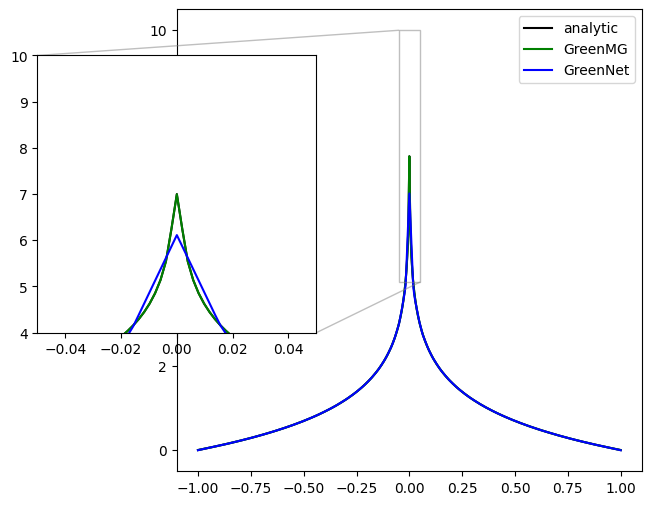

In [80]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(x, A_gt, '-k', label='analytic')
ax.plot(x, A_tgmg, '-g', label='GreenMG')
ax.plot(x, A_tgl, '-b', label='GreenNet')
axins = ax.inset_axes([-.3, 0.3, 0.6, 0.6], xlim=(-0.05, 0.05), ylim=(4,10))
axins.plot(x, A_gt, '-k', label='analytic')
axins.plot(x, A_tgmg, '-g', label='GreenMG')
axins.plot(x, A_tgl, '-b', label='GreenNet')
ax.indicate_inset_zoom(axins)
ax.legend()

Training Dynamics

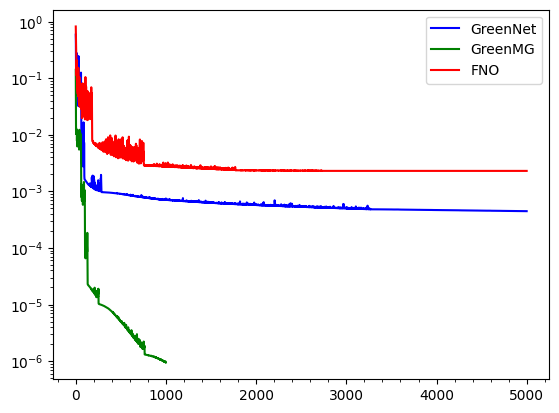

In [82]:
plt.plot(hist_tgl.test_rl2, '-b', label='GreenNet')
plt.plot(hist_tgmg.test_rl2, '-g', label='GreenMG')
plt.plot(hist_fno.test_rl2, '-r', label='FNO')
plt.legend()
plt.yscale('log')
# plt.ylim([0, 0.001])
plt.minorticks_on()

Laplace - 513

In [133]:
l = 9
n = 2**l+1
s = 2**l
x = torch.linspace(-1,1,2*n-1)

raw_data = scipy.io.loadmat('../../pde_data/green_learning/data1d_513/laplace.mat')
xh, yh = raw_data['X'], raw_data['Y']
x, y = np.meshgrid(xh, yh)
K_gt = eval(raw_data['ExactGreen'][0]).T

K_gl = np.load('../results/laplace_513/gl-relu-0/approx_kernel.npy')[0,0] * s
K_gmg = np.load('../results/laplace_513/dd_mg-5-3-1/approx_kernel.npy')[0] * s

# hist_tgl = pd.read_csv('../results/laplace_513/gl-relu-0/')
hist_gmg = pd.read_csv('../results/laplace_513/dd_mg-5-3-1/hist.csv')
hist_fno = pd.read_csv('../results/laplace_513/fno-0/hist.csv')

Text(0.5, 1.0, 'GreenMG-AbsError')

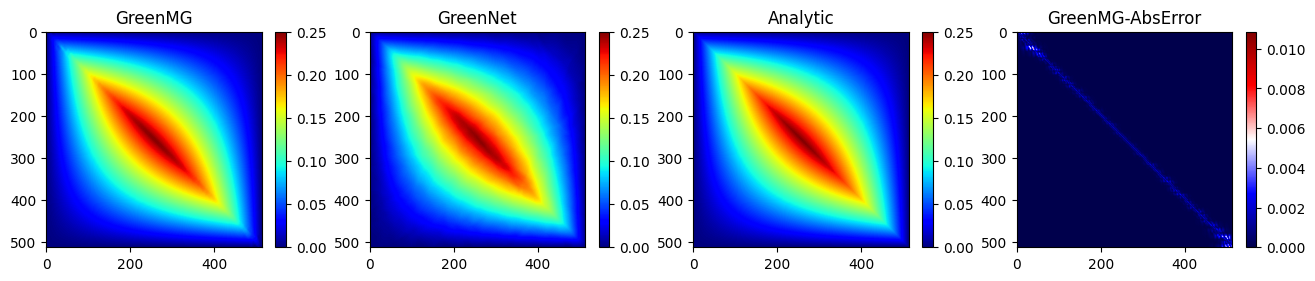

In [134]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(figsize=(16, 4), ncols=4)
gmg_fig = ax1.imshow(K_gmg, cmap='jet', vmax=K_gt.max(), vmin=K_gt.min())
ax1.set_title('GreenMG')
fig.colorbar(gmg_fig, ax=ax1, shrink=0.7)
gl_fig = ax2.imshow(K_gl, cmap='jet', vmax=K_gt.max(), vmin=K_gt.min())
fig.colorbar(gmg_fig, ax=ax2, shrink=0.7)
ax2.set_title('GreenNet')
gt_fig = ax3.imshow(K_gt, cmap='jet', vmax=K_gt.max(), vmin=K_gt.min())
fig.colorbar(gt_fig, ax=ax3, shrink=0.7)
ax3.set_title('Analytic')
err_fig = ax4.imshow(np.abs(K_gt-K_gmg), cmap='seismic')
fig.colorbar(err_fig, ax=ax4, shrink=0.7)
ax4.set_title('GreenMG-AbsError')

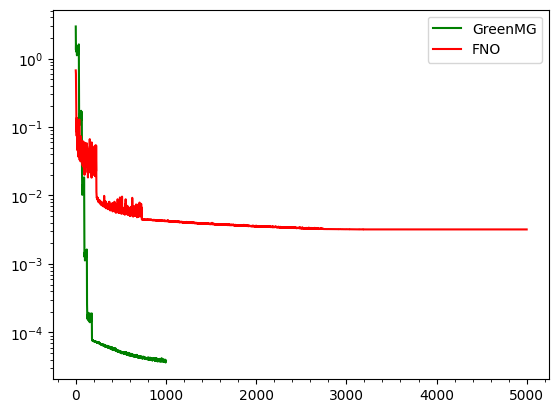

In [43]:
# plt.plot(hist_tgl.test_rl2, '-b', label='GreenNet')
plt.plot(hist_tgmg.test_rl2, '-g', label='GreenMG')
plt.plot(hist_fno.test_rl2, '-r', label='FNO')
plt.legend()
plt.yscale('log')
plt.minorticks_on()

Schrodinger - 513

In [149]:
l = 9
n = 2**l+1
s = 2**l
x = torch.linspace(-1,1,2*n-1)

# K_gmg = np.load('../results/schrodinger_513/dd_mg-1-3-1/approx_kernel.npy')[0] * s
K_gmg = np.load('../results/interior_layer_513/dd_mg-0-0-1/approx_kernel.npy')[0] * s


# # hist_tgl = pd.read_csv('../results/laplace_513/gl-relu-0/')
hist_gmg = pd.read_csv('../results/schrodinger_513/dd_mg-0-3-1/hist.csv')
hist_fno = pd.read_csv('../results/schrodinger_513/fno-0/hist.csv')

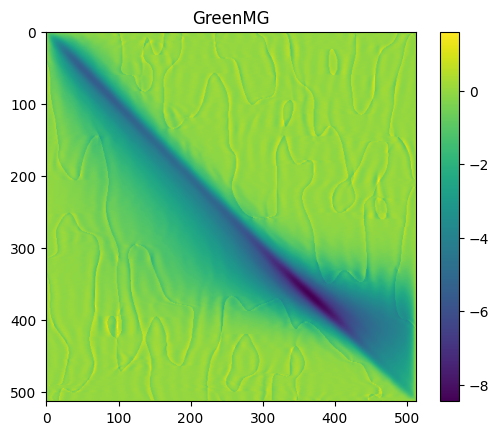

In [150]:
plt.imshow(K_gmg)
plt.title('GreenMG')
plt.colorbar()

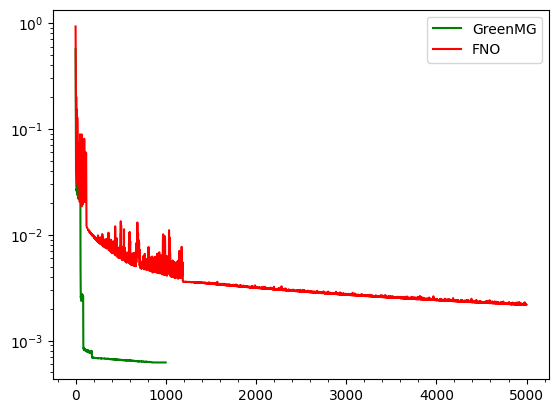

In [127]:
plt.plot(hist_gmg.test_rl2, '-g', label='GreenMG')
plt.plot(hist_fno.test_rl2, '-r', label='FNO')
plt.legend()
plt.yscale('log')
plt.minorticks_on()